# Introduction to Computational Physics: Problem Set 1
Tutorial: Chun Ming Yip (Group 3)

<hr>

## 1. Introduction
In this exercise we study a quantum particle of mass $m$ in the one-dimensional finite
square well potential
$$V(x) = \begin{cases}-V_0, & |x| < a, \\ 0, & |x| \ge a, \end{cases} \quad V_0 > 0.$$

The well has depth $V_0$ and width $2a$. We seek bound states with energy
$$-V_0 < E < 0$$

This problem is fundamental in quantum mechanics and leads to transcendental
equations that cannot be solved analytically. Therefore it is an excellent application
of numerical root finding.

## 2. Schrödinger Equation
The stationary Schrödinger equation is
$$-\frac{\hbar^2}{2m}\,\frac{d^2\psi}{dx^2}+V(x)\psi=E\psi.$$
Inside the well $(|x| < a)$, the solution is oscillatory,
$$\psi(x) = A\cos(kx) + B\sin(kx),\quad k = \sqrt{\frac{2m(E+V_0)}{\hbar^2}}.$$
Outside the well $(|x| ≥ a)$, bound states decay exponentially,
$$\psi(x) \propto e^{-\kappa |x|} , \quad \kappa = \sqrt{\frac{-2 m E}{\hbar^{2}}}.$$
Because the potential is symmetric, solutions have definite parity,
+ even states: $\psi(−x) = \psi(x)$
+ odd states: $\psi(−x) = -\psi(x)$

Matching $\psi$ and $\psi'$ at $x = a$ yields:

$$k\tan(ka)=\kappa \quad (\text{even states}) \\
-k\cot(ka)=\kappa \quad (\text{odd states}) $$

## 3. Dimensionless Form
Define
$$z = ka, \quad z_0 = a \sqrt{\frac{2mV_0}{\hbar^2}}.$$
Then
$$\kappa a = \sqrt{z_0^2 - z^2}.$$
Thus:
$$f_e(z) = z \tan(z) - \sqrt{z_0^2 - z^2} = 0 \\
f_o(z) = -z \cot(z) - \sqrt{z_0^2 - z^2} = 0 $$
with
$$0 < z < z_0.$$
Once a root $z$ is known, the energy follows from
$$E = \frac{\hbar^2 z^2}{2ma^2} - V_0.$$

<hr>

## Excersice 1: Insept the Functions
Use units
$$\hbar = 1, \quad m = 1, \quad a = 1.$$
Use $V_0 = 20$.
1. Inspect the function by plotting even and odd components for bound states.
Note characteristic features of the functions and discuss them. Make sure the
plot does not contain misleading lines! (1 pt.)
2. Write information output about the problem setup. For a given $V_0$ your code
should tell the user how many roots (approximately) will be expected. Also,
your code should esimate whether the roots are likely to be of multiplicity 1
(simple root). (1 pt.)

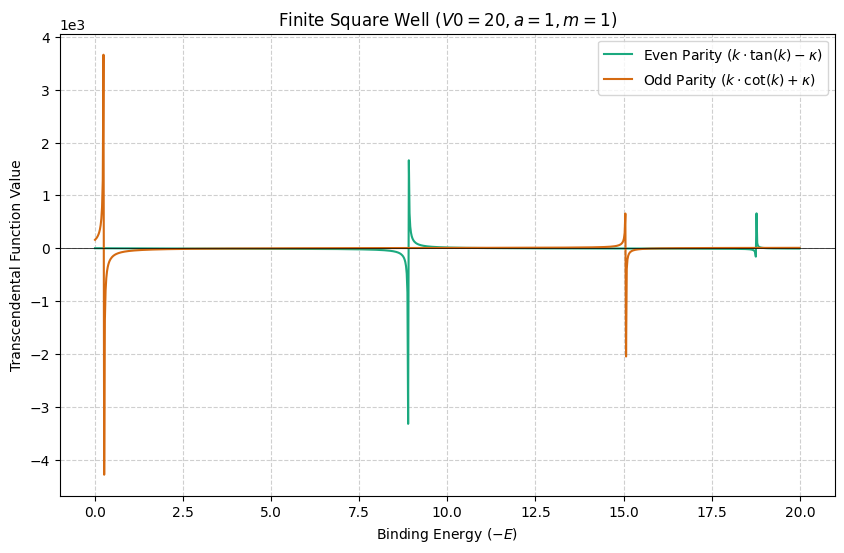

<Axes: title={'center': 'Finite Square Well ($V0=20, a=1, m = 1$)'}, xlabel='Binding Energy ($-E$)', ylabel='Transcendental Function Value'>

In [19]:
#   Excersice 1: PLOTTING
# ====================================================================================
# Libaries
import matplotlib.pyplot as plt
import numpy as np
import Papulator as pap # Custom Libary from other projects

# Defining constans
h_bar = 1
mass = 1
a = 1
width = 2 * a
V_0 = 20

# Energy variable epsilon = -E, range (0, V0)
eps = np.linspace(0.01, 19.99, 1000)

# Wave numbers (So simple because of natural Units system)
k = np.sqrt(2 * (V_0 - eps))
kappa = np.sqrt(2 * eps)

# ====================================================================================
# Even function: k*tan(k) - kappa
# ====================================================================================

# Handle singularities for tan
tan_k = np.tan(k)
# Set to NaN where cos(k) is close to 0 to avoid vertical lines
cos_k = np.cos(k)
mask_even = np.abs(cos_k) < 1e-3
tan_k[mask_even] = np.nan

f_even = k * tan_k - kappa


# ====================================================================================
# Odd function: -k*cot(k) - kappa  => -(k/tan(k)) - kappa
# ====================================================================================

# Handle singularities for cot (where sin(k) is close to 0)
sin_k = np.sin(k)
mask_odd = np.abs(sin_k) < 1e-3

cot_k = np.cos(k) / np.sin(k)
cot_k[mask_odd] = np.nan

f_odd = k * cot_k + kappa

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(
    eps, 
    f_even, 
    label=r'Even Parity ($k \cdot \tan(k) - \kappa$)',

    )
plt.plot(
    eps, 
    f_odd, 
    label=r'Odd Parity ($k \cdot \cot(k) + \kappa$)', 
    # linestyle='--'
    )

plt.axhline(0, color='black', linewidth=0.5)



# # Spike 1
# plt.xlim(0,1)

# # Spike 2
# plt.xlim(8.5,9.5)

# # Spike 3
# plt.xlim(14.5,15.5)

# # Spike 4
# plt.xlim(18.5,19.5)

# # Fokus on roots
# plt.ylim(-0.7,0.7)

pap.plot_me(f'Finite Square Well ($V0={V_0}, a={a}, m = {mass}$)', 'Binding Energy ($-E$)', 'Transcendental Function Value')

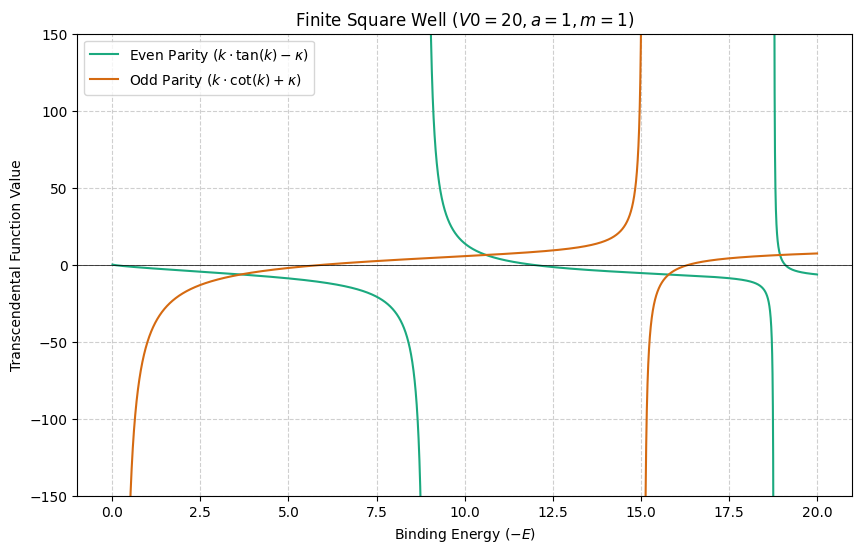

<Axes: title={'center': 'Finite Square Well ($V0=20, a=1, m = 1$)'}, xlabel='Binding Energy ($-E$)', ylabel='Transcendental Function Value'>

In [20]:
#   Excersice 1: PLOTTING WITH FOKUS ON ROOTS
# ====================================================================================
# Libaries
import matplotlib.pyplot as plt
import numpy as np
import Papulator as pap # Custom Libary from other projects

# Defining constans
h_bar = 1
mass = 1
a = 1
width = 2 * a
V_0 = 20

# Energy variable epsilon = -E, range (0, V0)
eps = np.linspace(0.01, 19.99, 10000)

# Wave numbers (So simple because of natural Units system)
k = np.sqrt(2 * (V_0 - eps))
kappa = np.sqrt(2 * eps)

# ====================================================================================
# Even function: k*tan(k) - kappa
# ====================================================================================

# Handle singularities for tan
tan_k = np.tan(k)
# Set to NaN where cos(k) is close to 0 to avoid vertical lines
cos_k = np.cos(k)
mask_even = np.abs(cos_k) < 1e-3
tan_k[mask_even] = np.nan

f_even = k * tan_k - kappa


# ====================================================================================
# Odd function: -k*cot(k) - kappa  => -(k/tan(k)) - kappa
# ====================================================================================

# Handle singularities for cot (where sin(k) is close to 0)
sin_k = np.sin(k)
mask_odd = np.abs(sin_k) < 1e-3

cot_k = np.cos(k) / np.sin(k)
cot_k[mask_odd] = np.nan

f_odd = k * cot_k + kappa

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(
    eps, 
    f_even, 
    label=r'Even Parity ($k \cdot \tan(k) - \kappa$)',
    )

plt.plot(
    eps, 
    f_odd, 
    label=r'Odd Parity ($k \cdot \cot(k) + \kappa$)', 
    # linestyle='--'
    )

plt.axhline(0, color='black', linewidth=0.5)

# # Fokus on roots
plt.ylim(-150,150)
# plt.ylim(-1.50,1.50)

pap.plot_me(f'Finite Square Well ($V0={V_0}, a={a}, m = {mass}$)', 'Binding Energy ($-E$)', 'Transcendental Function Value')

Notice: Setting the linespace to 1,000 also fixed the vertical line problem.

z0 = 6.3246
Expected bound states: ~3


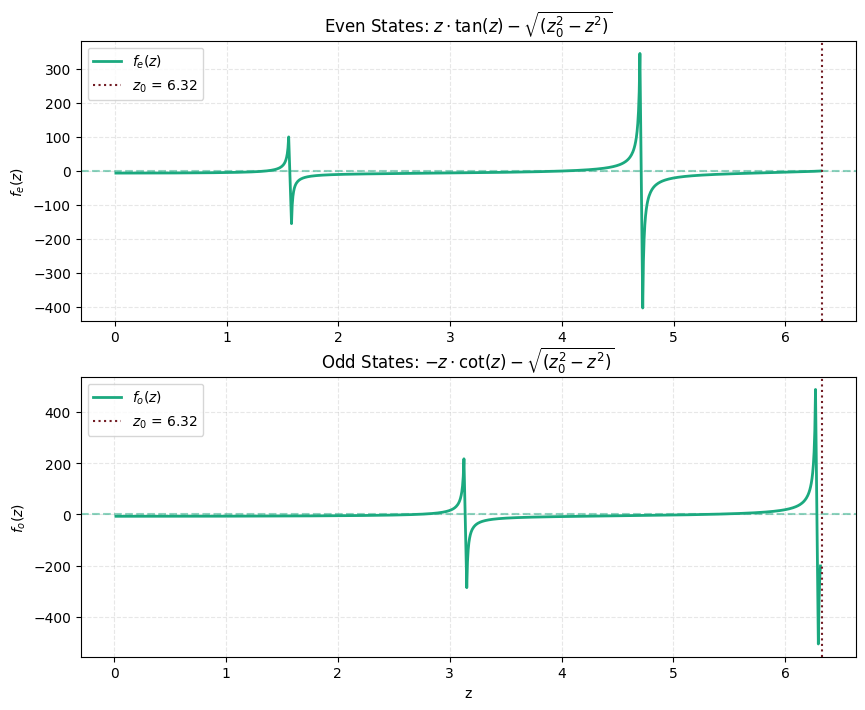

<Axes: title={'center': 'Odd States: $-z \\cdot \\cot(z) - \\sqrt{(z_0^2 - z^2)}$'}, xlabel='z', ylabel='$f_o(z)$'>

In [21]:
#   Excersice 1: PLOTTING and do it the intend way
# ====================================================================================

# Parameters
h_bar = 1
m = 1
a = 1
V_0 = 20

# Calculate z0
z_0 = a * np.sqrt(2 * m * V_0 / h_bar**2)
print(f"z0 = {z_0:.4f}")
print(f"Expected bound states: ~{int(z_0/np.pi) + 1}")

# Define the functions (avoiding singularities)
def f_even(z):
    return z * np.tan(z) - np.sqrt(z_0**2 - z**2)

def f_odd(z):
    return -z / np.tan(z) - np.sqrt(z_0**2 - z**2)

# Create z array, avoiding singularities at z = pi/2, 3pi/2, ...
z = np.linspace(0.01, z_0 - 0.01, 1000)

# Handle singularities by masking
mask_even = np.abs(np.cos(z)) > 0.01  # tan(z) blows up when cos(z) \approx 0
mask_odd = np.abs(np.sin(z)) > 0.01   # cot(z) blows up when sin(z) \approx 0

# Plot
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Even states
axes[0].plot(
    z[mask_even],
    f_even(z)[mask_even], 
    linewidth=2, 
    label='$f_e(z)$'
    )

# Line at 0
axes[0].axhline(y=0, linestyle='--', alpha=0.5)

# Line marking z_0
axes[0].axvline(x=z_0, linestyle=':', label=f'$z_0$ = {z_0:.2f}', color=pap.Colors.WINE_RED)

axes[0].set_ylabel('$f_e(z)$')
axes[0].set_title(r'Even States: $z \cdot \tan(z) - \sqrt{(z_0^2 - z^2)}$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Odd states
axes[1].plot(
    z[mask_odd], 
    f_odd(z)[mask_odd], 
    linewidth=2, 
    label='$f_o(z)$')

axes[1].axhline(y=0, linestyle='--', alpha=0.5)
axes[1].axvline(x=z_0, linestyle=':', label=fr'$z_0$ = {z_0:.2f}', color=pap.Colors.WINE_RED)
axes[1].set_xlabel('z')
axes[1].set_ylabel('$f_o(z)$')
axes[1].set_title(r'Odd States: $-z \cdot \cot(z) - \sqrt{(z_0^2 - z^2)}$')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

pap.plot_me()

Looking at the roots we see that all roots should be of multiplicity 1, since the function is somoot between the singulrities (peaks of tan/cotan), the slop at (around) the root point is $\not = 0$ and around the corssings there is no degenerate distribution (the function is continuous around the roots.)

<hr>

## Exercise 2: Root Finding
Implement the following methods: (5 pt.)
+ bisection
+ Newton method
+ secant method

Use all of them to compute one selected root. For each method measure and comment
on (3 pt.)
+ number of iterations
+ runtime
+ final residual

<hr>

## Exercise 3: Automatic Detection of All Roots
Construct an automated algorithm that finds all roots of $f_e(z) = 0 and f_o(z) = 0$ in
the interval $0 < z < z_0$. Split the interval in a clever way. Compute all bound-state
energies. Why is the parity-separated formulation numerically useful?

<hr>

## Exercise 4: Speed vs Accuracy (3 pt.)
For one root compare the methods for tolerances
$$10^{−4}, 10^{−8}, 10^{−12}.$$
Create:
+ a table of iterations and runtime
+ a plot of runtime vs residual
+ a short discussion

<hr>

## Exercise 5: Dependence on Well Depth (optional 3 pt.)
Repeat the analysis for
$$V_0 = 5, 10, 20, 50.$$
Comment on the number of bound states and on the behaviour of the roots with
increasing $V_0$ (location/slope). What happens for $V_0 \to \infty$? Comment on the accuracy
of a root $z$ for a given stopping criterion based on the value of $f(z) (|f (z)| < eps)$.